In [19]:
import matplotlib.pyplot as plt
import pandas as pd

In [20]:
df_all = pd.read_csv("../datasets_raw/AGGREGATED_GENERATION_PER_TYPE_GENERATION_201812312300-201912312300.csv")

C:\Users\lackn\AppData\Local\Temp\ipykernel_17988\3283298615.py:1: DtypeWarning: Columns (0: Generation (MW)) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv("./datasets/AGGREGATED_GENERATION_PER_TYPE_GENERATION_201812312300-201912312300.csv")


In [21]:
df_wind_offshore = df_all[df_all["Production Type"] == "Wind Offshore"]
df_wind_offshore.columns = ['MTU', 'Area', 'Production_Type', 'Generation_MW']
df_wind_offshore = df_wind_offshore.drop(columns=['Area', 'Production_Type'])

In [22]:
df_wind_offshore['Time'] = df_wind_offshore['MTU'].str.split(' - ').str[0]
df_wind_offshore['Time'] = df_wind_offshore['Time'].str.replace(r'\s*\(.*?\)', '', regex=True).str.strip()
df_wind_offshore['Time'] = pd.to_datetime(df_wind_offshore['Time'], format='%d/%m/%Y %H:%M:%S')

# Convert generation to numeric
df_wind_offshore['Generation_MW'] = pd.to_numeric(df_wind_offshore['Generation_MW'], errors='coerce')

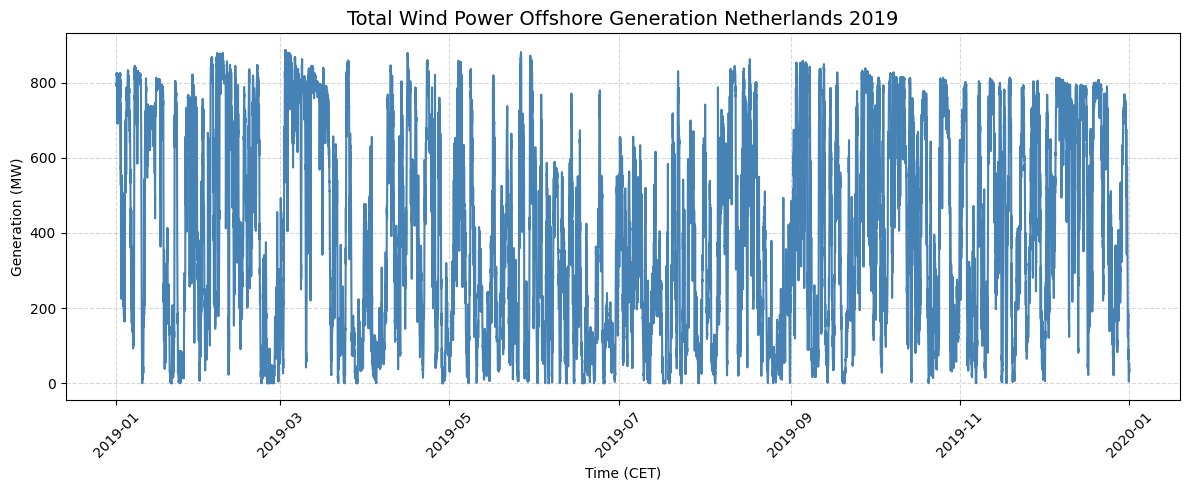

In [25]:
# Plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_wind_offshore['Time'], df_wind_offshore['Generation_MW'], color='steelblue', linewidth=1.5)

ax.set_title('Total Wind Power Offshore Generation Netherlands 2019', fontsize=14)
ax.set_xlabel('Time (CET)')
ax.set_ylabel('Generation (MW)')
ax.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('wind_onshore_timeseries.png', dpi=150)
plt.show()

In [24]:
# Calculate descriptive statistics
stats = df_wind_offshore[['Generation_MW']].describe()
stats = stats.round(2)
print(stats)

        Generation_MW
count        35040.00
mean           402.00
std            277.15
min              0.00
25%            143.91
median         368.85
75%            671.90
max            886.88
